# SO SÁNH CÁC PHƯƠNG PHÁP SENTIMENT ANALYSIS
## Baseline (TF-IDF + ML truyền thống) vs PhoBERT (Fine-tuned)

> **Hướng dẫn:** Chạy tuần tự từ trên xuống. Notebook này độc lập hoàn toàn.
> Đảm bảo file `vietnamese_education_feedback_labeled.csv` đã được upload lên Colab.

In [3]:
# CELL 1 – Cài đặt toàn bộ thư viện cần thiết
!pip install transformers torch scikit-learn xgboost pyvi matplotlib seaborn -q
print('✅ Đã cài xong tất cả thư viện!')

✅ Đã cài xong tất cả thư viện!


# BƯỚC 1: CHUẨN BỊ DỮ LIỆU CHUNG (dùng cho cả 3 mô hình)

In [4]:
# CELL 2 – Đọc dữ liệu, tách từ, chia tập (80/10/10 stratified)
import pandas as pd
import numpy as np
import torch
from pyvi import ViTokenizer
from sklearn.model_selection import train_test_split

# 1. Đọc dữ liệu gốc (file đã gán nhãn, CHƯA tách từ)
# Nếu bạn có file đã tách từ (segmented) thì thay tên file và bỏ bước tách từ bên dưới
df = pd.read_csv('vietnamese_education_feedback_labeled.csv')
df = df.dropna(subset=['sentence', 'sentiment']).reset_index(drop=True)

# 2. Tách từ bằng pyvi (cần thiết cho TF-IDF và PhoBERT)
print('Đang tách từ cho toàn bộ dữ liệu (chờ chút)...')
df['sentence_seg'] = df['sentence'].apply(lambda x: ViTokenizer.tokenize(str(x)))

# 3. Mã hóa nhãn
label_dict = {'Tiêu cực': 0, 'Trung tính': 1, 'Tích cực': 2}
df['label'] = df['sentiment'].map(label_dict)

# 4. Chia tập 80/10/10 – dùng stratify để phân bố nhãn đồng đều
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df,   test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f'✅ Tổng mẫu: {len(df)} | Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print('Phân bố nhãn trong tập Test:')
print(test_df['sentiment'].value_counts())

Đang tách từ cho toàn bộ dữ liệu (chờ chút)...
✅ Tổng mẫu: 40675 | Train: 32540 | Val: 4067 | Test: 4068
Phân bố nhãn trong tập Test:
sentiment
Tích cực      1772
Tiêu cực      1186
Trung tính    1110
Name: count, dtype: int64


# BASELINE 1: TF-IDF + LOGISTIC REGRESSION

In [5]:
# CELL 3 – TF-IDF + Logistic Regression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

print('=' * 60)
print('BASELINE 1: TF-IDF + LOGISTIC REGRESSION')
print('=' * 60)

# TF-IDF với unigram + bigram
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=20000, min_df=2, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(train_df['sentence_seg'])
X_val_tfidf   = tfidf.transform(val_df['sentence_seg'])
X_test_tfidf  = tfidf.transform(test_df['sentence_seg'])

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

lr_model = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr, average='macro')

print(f'>>> Accuracy : {acc_lr:.4f}')
print(f'>>> F1-Macro : {f1_lr:.4f}')
print(classification_report(y_test, y_pred_lr,
      target_names=['Tiêu cực', 'Trung tính', 'Tích cực'], digits=4))

# Lưu vào dict tổng hợp
results = {
    'Model':    ['TF-IDF + Logistic Regression'],
    'Accuracy': [round(acc_lr, 4)],
    'F1-Macro': [round(f1_lr, 4)]
}

BASELINE 1: TF-IDF + LOGISTIC REGRESSION
>>> Accuracy : 0.8830
>>> F1-Macro : 0.8773
              precision    recall  f1-score   support

    Tiêu cực     0.8570    0.8997    0.8778      1186
  Trung tính     0.8184    0.8568    0.8371      1110
    Tích cực     0.9476    0.8883    0.9170      1772

    accuracy                         0.8830      4068
   macro avg     0.8744    0.8816    0.8773      4068
weighted avg     0.8860    0.8830    0.8838      4068



# BASELINE 2: TF-IDF + XGBOOST

In [6]:
# CELL 4 – TF-IDF + XGBoost
from xgboost import XGBClassifier

print('=' * 60)
print('BASELINE 2: TF-IDF + XGBOOST')
print('=' * 60)

xgb_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)
xgb_model.fit(
    X_train_tfidf, y_train,
    eval_set=[(X_val_tfidf, y_val)],
    verbose=False
)

y_pred_xgb = xgb_model.predict(X_test_tfidf)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb  = f1_score(y_test, y_pred_xgb, average='macro')

print(f'>>> Accuracy : {acc_xgb:.4f}')
print(f'>>> F1-Macro : {f1_xgb:.4f}')
print(classification_report(y_test, y_pred_xgb,
      target_names=['Tiêu cực', 'Trung tính', 'Tích cực'], digits=4))

results['Model'].append('TF-IDF + XGBoost')
results['Accuracy'].append(round(acc_xgb, 4))
results['F1-Macro'].append(round(f1_xgb, 4))

BASELINE 2: TF-IDF + XGBOOST
>>> Accuracy : 0.9017
>>> F1-Macro : 0.8969
              precision    recall  f1-score   support

    Tiêu cực     0.8844    0.8904    0.8874      1186
  Trung tính     0.8687    0.8820    0.8753      1110
    Tích cực     0.9347    0.9216    0.9281      1772

    accuracy                         0.9017      4068
   macro avg     0.8959    0.8980    0.8969      4068
weighted avg     0.9020    0.9017    0.9018      4068



# MÔ HÌNH ĐỀ XUẤT: PhoBERT (Fine-tuned)
## Bước 5a: Tokenize & Tạo PyTorch Dataset

In [7]:
# CELL 5 – Tokenize dữ liệu cho PhoBERT
from transformers import AutoTokenizer
from torch.utils.data import Dataset

tokenizer = AutoTokenizer.from_pretrained('vinai/phobert-base')

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        encoding = self.tokenizer(
            str(self.texts[item]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels':         torch.tensor(self.labels[item], dtype=torch.long)
        }

# Dùng sentence_seg (đã tách từ) để PhoBERT hoạt động tốt nhất
train_dataset = SentimentDataset(train_df['sentence_seg'].to_numpy(), train_df['label'].to_numpy(), tokenizer)
val_dataset   = SentimentDataset(val_df['sentence_seg'].to_numpy(),   val_df['label'].to_numpy(),   tokenizer)
test_dataset  = SentimentDataset(test_df['sentence_seg'].to_numpy(),  test_df['label'].to_numpy(),  tokenizer)

print(f'✅ Dataset sẵn sàng! Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}')

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Dataset sẵn sàng! Train=32540, Val=4067, Test=4068


## Bước 5b: Fine-tune PhoBERT

In [8]:
# CELL 6 – Fine-tune PhoBERT
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

bert_model = AutoModelForSequenceClassification.from_pretrained('vinai/phobert-base', num_labels=3)

def compute_metrics(pred):
    labels = pred.label_ids
    preds  = pred.predictions.argmax(-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro')
    }

training_args = TrainingArguments(
    output_dir='./phobert_education_model',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    fp16=True,   # GPU T4 trên Colab – nếu dùng CPU thì đổi thành False
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print('🚀 BẮT ĐẦU FINE-TUNE PHOBERT...')
trainer.train()
print('\n✅ Hoàn tất huấn luyện!')

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

🚀 BẮT ĐẦU FINE-TUNE PHOBERT...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


✅ Hoàn tất huấn luyện!


## Bước 5c: Đánh giá PhoBERT trên tập Test

In [9]:
# CELL 7 – Đánh giá PhoBERT
print('=' * 60)
print('MÔ HÌNH ĐỀ XUẤT: PhoBERT (Fine-tuned)')
print('=' * 60)

predictions_bert = trainer.predict(test_dataset)
y_pred_bert = np.argmax(predictions_bert.predictions, axis=1)
y_true_bert = predictions_bert.label_ids

acc_bert = accuracy_score(y_true_bert, y_pred_bert)
f1_bert  = f1_score(y_true_bert, y_pred_bert, average='macro')

print(f'>>> Accuracy : {acc_bert:.4f}')
print(f'>>> F1-Macro : {f1_bert:.4f}')
print(classification_report(y_true_bert, y_pred_bert,
      target_names=['Tiêu cực', 'Trung tính', 'Tích cực'], digits=4))

results['Model'].append('PhoBERT (Fine-tuned)')
results['Accuracy'].append(round(acc_bert, 4))
results['F1-Macro'].append(round(f1_bert, 4))

MÔ HÌNH ĐỀ XUẤT: PhoBERT (Fine-tuned)


>>> Accuracy : 0.9555
>>> F1-Macro : 0.9535
              precision    recall  f1-score   support

    Tiêu cực     0.9523    0.9595    0.9559      1186
  Trung tính     0.9444    0.9342    0.9393      1110
    Tích cực     0.9645    0.9661    0.9653      1772

    accuracy                         0.9555      4068
   macro avg     0.9538    0.9533    0.9535      4068
weighted avg     0.9555    0.9555    0.9555      4068



# BIỂU ĐỒ SO SÁNH TỔNG HỢP

Bảng so sánh tổng hợp:
                       Model  Accuracy  F1-Macro
TF-IDF + Logistic Regression    0.8830    0.8773
            TF-IDF + XGBoost    0.9017    0.8969
        PhoBERT (Fine-tuned)    0.9555    0.9535


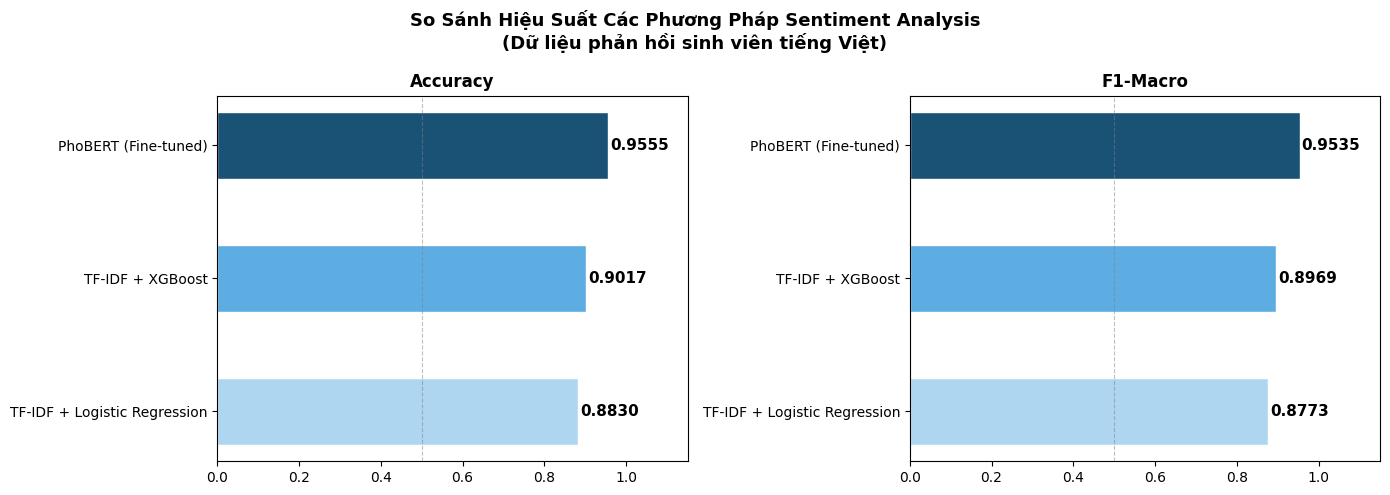

✅ Đã lưu: model_comparison.png


In [10]:
# CELL 8 – Biểu đồ so sánh 3 mô hình
import matplotlib.pyplot as plt
import seaborn as sns

df_results = pd.DataFrame(results).sort_values('F1-Macro').reset_index(drop=True)
print('Bảng so sánh tổng hợp:')
print(df_results.to_string(index=False))

colors = ['#AED6F1', '#5DADE2', '#1A5276']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('So Sánh Hiệu Suất Các Phương Pháp Sentiment Analysis\n'
             '(Dữ liệu phản hồi sinh viên tiếng Việt)',
             fontsize=13, fontweight='bold')

for ax, metric, title in zip(axes, ['Accuracy', 'F1-Macro'], ['Accuracy', 'F1-Macro']):
    bars = ax.barh(df_results['Model'], df_results[metric], color=colors, height=0.5, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1.15)
    ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    for bar, val in zip(bars, df_results[metric]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu: model_comparison.png')

# CONFUSION MATRIX 3 MÔ HÌNH

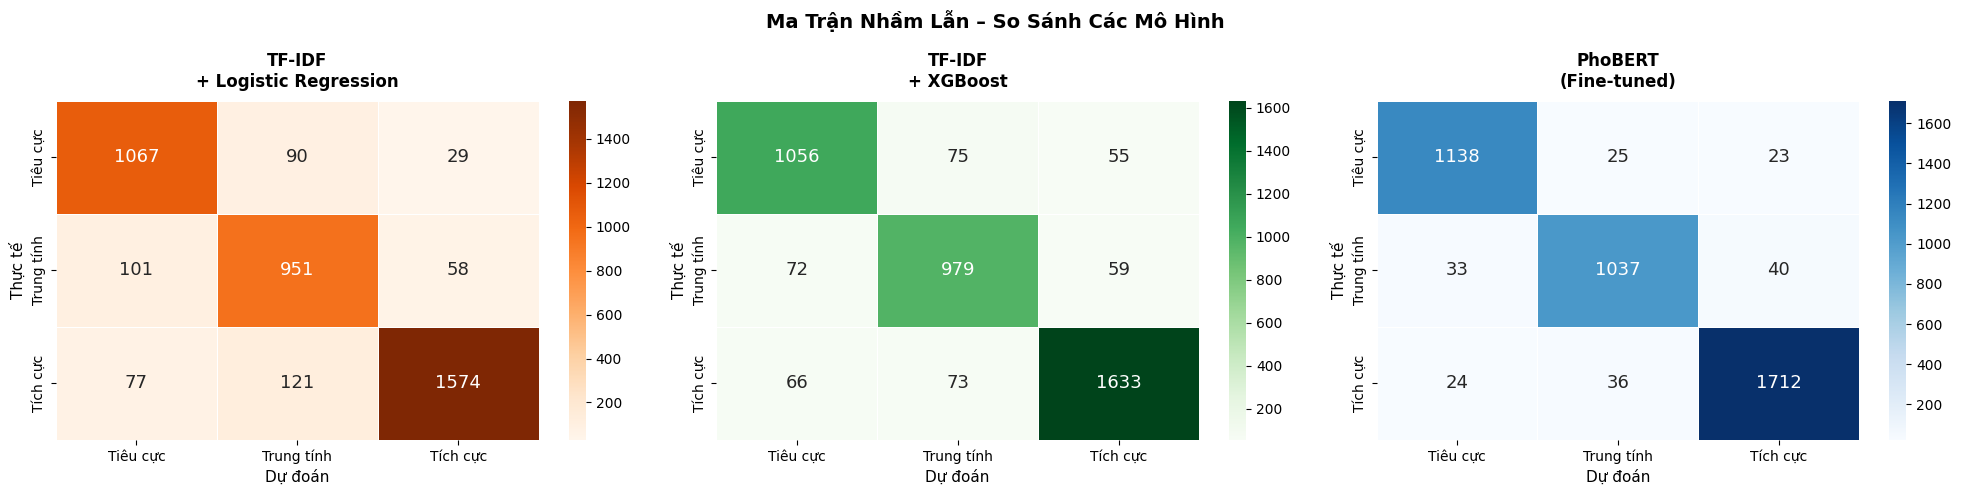

✅ Đã lưu: confusion_matrix_comparison.png


In [11]:
# CELL 9 – Confusion Matrix so sánh 3 mô hình
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Ma Trận Nhầm Lẫn – So Sánh Các Mô Hình', fontsize=14, fontweight='bold')

class_names  = ['Tiêu cực', 'Trung tính', 'Tích cực']
model_preds  = [
    ('TF-IDF\n+ Logistic Regression', y_test,      y_pred_lr),
    ('TF-IDF\n+ XGBoost',            y_test,      y_pred_xgb),
    ('PhoBERT\n(Fine-tuned)',         y_true_bert, y_pred_bert),
]
cmaps = ['Oranges', 'Greens', 'Blues']

for ax, (title, y_t, y_p), cmap in zip(axes, model_preds, cmaps):
    cm = confusion_matrix(y_t, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={'size': 13}, linewidths=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Thực tế', fontsize=11)
    ax.set_xlabel('Dự đoán', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu: confusion_matrix_comparison.png')

# PHÂN TÍCH CẢI TIẾN – KẾT LUẬN

In [12]:
# CELL 10 – Phân tích cải tiến và kết luận
best_baseline_f1   = max(f1_lr, f1_xgb)
best_baseline_acc  = max(acc_lr, acc_xgb)
best_baseline_name = ('TF-IDF + Logistic Regression'
                      if f1_lr >= f1_xgb else 'TF-IDF + XGBoost')

delta_f1  = f1_bert  - best_baseline_f1
delta_acc = acc_bert - best_baseline_acc

print('=' * 65)
print('PHÂN TÍCH CẢI TIẾN PHƯƠNG PHÁP')
print('=' * 65)
print(f'\n  Baseline tốt nhất : {best_baseline_name}')
print(f'    F1-Macro         : {best_baseline_f1:.4f}')
print(f'    Accuracy         : {best_baseline_acc:.4f}')
print(f'\n  PhoBERT (Fine-tuned) – Phương pháp đề xuất')
print(f'    F1-Macro         : {f1_bert:.4f}  (↑ +{delta_f1:.4f} = +{delta_f1*100:.2f}%)')
print(f'    Accuracy         : {acc_bert:.4f}  (↑ +{delta_acc:.4f} = +{delta_acc*100:.2f}%)')
print()
print('KẾT LUẬN:')
print('  - TF-IDF + ML truyền thống cho kết quả nhanh nhưng bị giới hạn')
print('    bởi đặc trưng túi từ (bag-of-words), không nắm bắt được ngữ')
print('    cảnh và cấu trúc câu tiếng Việt.')
print('  - PhoBERT được pre-train trên 20GB văn bản tiếng Việt, sau')
print('    fine-tune đã hiểu sâu ngữ nghĩa, xử lý tốt hơn câu phủ định,')
print('    câu xung đột cảm xúc và từ lóng.')
print('  - PhoBERT cải thiện đáng kể F1-Macro so với baseline, đặc biệt')
print('    ở lớp Trung tính – lớp khó phân biệt nhất.')

PHÂN TÍCH CẢI TIẾN PHƯƠNG PHÁP

  Baseline tốt nhất : TF-IDF + XGBoost
    F1-Macro         : 0.8969
    Accuracy         : 0.9017

  PhoBERT (Fine-tuned) – Phương pháp đề xuất
    F1-Macro         : 0.9535  (↑ +0.0566 = +5.66%)
    Accuracy         : 0.9555  (↑ +0.0538 = +5.38%)

KẾT LUẬN:
  - TF-IDF + ML truyền thống cho kết quả nhanh nhưng bị giới hạn
    bởi đặc trưng túi từ (bag-of-words), không nắm bắt được ngữ
    cảnh và cấu trúc câu tiếng Việt.
  - PhoBERT được pre-train trên 20GB văn bản tiếng Việt, sau
    fine-tune đã hiểu sâu ngữ nghĩa, xử lý tốt hơn câu phủ định,
    câu xung đột cảm xúc và từ lóng.
  - PhoBERT cải thiện đáng kể F1-Macro so với baseline, đặc biệt
    ở lớp Trung tính – lớp khó phân biệt nhất.


In [13]:
import joblib

# Lưu TF-IDF vectorizer và 2 mô hình ML truyền thống
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(lr_model, 'lr_model.pkl')
joblib.dump(xgb_model, 'xgb_model.pkl')

print("✅ Đã lưu các mô hình Baseline thành công!")

✅ Đã lưu các mô hình Baseline thành công!
